# 📊 Analisis Segmentasi Pengguna E-Commerce X dengan K-Modes Clustering

## 🧩 Problem Statement

Pada project ini, saya akan menganalisis **K-Modes Clustering** untuk melihat bagaimana segmentasi pengguna pada E-Commerce X berdasarkan dua aspek berikut:

### 1. Demographic Segmentation

Analisis segmentasi ini bertujuan untuk membantu strategi **advertising** serta **rekomendasi produk** berdasarkan kelompok pelanggan tertentu.

Goals:
- Membantu dalam membuat **buyer/customer persona** → *personalized marketing*
- Mendukung strategi **targeted advertising** (misalnya: *Impulsive Young Professional* atau *Promo Savvy Buyer*)

### 2. Behavioral Segmentation

Analisis ini fokus pada interaksi pengguna terhadap produk dan layanan E-Commerce.

Goals:
- Memahami **behavior** dari setiap segmen
- Mengidentifikasi segmen pelanggan yang **loyal** → Memberikan *promotion* atau *special offer* yang tepat

---

## Metode Analisis Data

- Menggunakan algoritma **K-Modes Clustering** yang cocok untuk data kategorikal
- Mengelompokkan pengguna berdasarkan atribut **demografis** dan **perilaku**
- Visualisasi hasil clustering untuk interpretasi lebih lanjut

---

> 📌 *K-Modes adalah varian dari K-Means yang dirancang khusus untuk menangani data kategorikal, dengan menggunakan mode (modus) sebagai pusat cluster dan dissimilarity berdasarkan jumlah ketidaksesuaian kategori.*

### Importing Library

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
from ydata_profiling import ProfileReport
warnings.filterwarnings("ignore")

# Data Understanding

Dataset ini menyediakan kumpulan data perilaku konsumen yang komprehensif yang dapat digunakan untuk berbagai riset pasar dan analisis statistik. Dataset ini mencakup informasi tentang pola pembelian, demografi, preferensi produk, kepuasan pelanggan, dan banyak lagi, sehingga ideal untuk segmentasi pasar, pemodelan prediktif, dan pemahaman proses pengambilan keputusan pelanggan.

Source Dataset : https://www.kaggle.com/datasets/salahuddinahmedshuvo/ecommerce-consumer-behavior-analysis-data

Dataset ini dirancang untuk membantu peneliti, data scientist, dan pemasar dalam mendapatkan wawasan mendalam terkait perilaku pembelian konsumen di berbagai kategori. Melalui analisis dataset ini, pengguna dapat mengidentifikasi tren utama, melakukan segmentasi pelanggan, serta mengambil keputusan berbasis data untuk meningkatkan penawaran produk, strategi pemasaran, dan keterlibatan pelanggan.

| No. | Column Name                     | Description                                                                                  |
|-----|----------------------------------|----------------------------------------------------------------------------------------------|
| 1   | Customer_ID                     | Unique identifier for each customer.                                                         |
| 2   | Age                             | Customer's age (integer).                                                                    |
| 3   | Gender                          | Customer's gender (categorical: Male, Female, Non-binary, Other).                           |
| 4   | Income_Level                    | Customer's income level (categorical: Low, Middle, High).                                   |
| 5   | Marital_Status                  | Customer's marital status (categorical: Single, Married, Divorced, Widowed).                |
| 6   | Education_Level                 | Highest level of education completed (categorical: High School, Bachelor's, Master's, Doctorate). |
| 7   | Occupation                      | Customer's occupation (categorical: Various job titles).                                     |
| 8   | Location                        | Customer's location (city, region, or country).                                               |
| 9   | Purchase_Category               | Category of purchased products (e.g., Electronics, Clothing, Groceries).                     |
| 10  | Purchase_Amount                 | Amount spent during the purchase (decimal).                                                  |
| 11  | Frequency_of_Purchase          | Number of purchases made per month (integer).                                                |
| 12  | Purchase_Channel               | The purchase method (categorical: Online, In-Store, Mixed).                                  |
| 13  | Brand_Loyalty                   | Loyalty to brands (1-5 scale).                                                               |
| 14  | Product_Rating                 | Rating given by the customer to a purchased product (1-5 scale).                             |
| 15  | Time_Spent_on_Product_Research | Time spent researching a product (integer, hours or minutes).                                |
| 16  | Social_Media_Influence         | Influence of social media on purchasing decision (categorical: High, Medium, Low, None).     |
| 17  | Discount_Sensitivity           | Sensitivity to discounts (categorical: Very Sensitive, Somewhat Sensitive, Not Sensitive).   |
| 18  | Return_Rate                    | Percentage of products returned (decimal).                                                   |
| 19  | Customer_Satisfaction          | Overall satisfaction with the purchase (1-10 scale).                                         |
| 20  | Engagement_with_Ads            | Engagement level with advertisements (categorical: High, Medium, Low, None).                |
| 21  | Device_Used_for_Shopping       | Device used for shopping (categorical: Smartphone, Desktop, Tablet).                         |
| 22  | Payment_Method                 | Method of payment used (categorical: Credit Card, Debit Card, PayPal, Cash, Other).          |
| 23  | Time_of_Purchase               | Timestamp of when the purchase was made (date/time).                                         |
| 24  | Discount_Used                  | Whether the customer used a discount (Boolean: True/False).                                  |
| 25  | Customer_Loyalty_Program_Member | Whether the customer is part of a loyalty program (Boolean: True/False).                    |
| 26  | Purchase_Intent                | The intent behind the purchase (categorical: Impulsive, Planned, Need-based, Wants-based).   |
| 27  | Shipping_Preference            | Shipping preference (categorical: Standard, Express, No Preference).                         |
| 28  | Payment_Frequency              | Frequency of payment (categorical: One-time, Subscription, Installments).                    |
| 29  | Time_to_Decision               | Time taken from consideration to actual purchase (in days).                                  |


In [68]:
df = pd.read_csv("Ecommerce_Consumer_Behavior_Analysis_Data.csv")
df

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,20-562-2569,44,Female,High,Divorced,Bachelor's,High,Aramayuan,Mobile Accessories,$463.67,...,4,NaN,Tablet,PayPal,7/7/2024,True,False,Need-based,Standard,5
996,41-366-4205,50,Female,High,Single,High School,Middle,Paquera,Gardening & Outdoors,$69.78,...,6,Low,Tablet,Cash,3/28/2024,True,False,Wants-based,No Preference,9
997,77-241-7621,26,Male,High,Married,Bachelor's,High,Warudoyong,Food & Beverages,$453.37,...,6,High,Desktop,Credit Card,3/11/2024,True,True,Wants-based,Express,9
998,53-091-2176,21,Female,High,Widowed,Bachelor's,Middle,Béziers,Baby Products,$106.15,...,5,Medium,Desktop,Cash,3/30/2024,True,True,Impulsive,Standard,8


In [69]:
profile = ProfileReport(df, explorative= True)
display(profile)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 28/28 [00:00<00:00, 386.99it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [70]:
print(f"Count of Row and Column : {df.shape}")
display(df.info(max_cols= None), df.describe(),df.describe(include="O"))

Count of Row and Column : (1000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase               

None

,Age,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_to_Decision
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.304000,6.945000,3.026000,3.033000,1.013030,0.954000,5.399000,7.547000
std,9.353238,3.147361,1.416803,1.436654,0.791802,0.810272,2.868454,4.035849
min,18.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,26.000000,4.000000,2.000000,2.000000,0.000000,0.000000,3.000000,4.000000
50%,34.500000,7.000000,3.000000,3.000000,1.000000,1.000000,5.000000,8.000000
75%,42.000000,10.000000,4.000000,4.000000,2.000000,2.000000,8.000000,11.000000
max,50.000000,12.000000,5.000000,5.000000,2.000000,2.000000,10.000000,14.000000


,Customer_ID,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,Purchase_Channel,Social_Media_Influence,Discount_Sensitivity,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Purchase_Intent,Shipping_Preference
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,753,1000,744,1000,1000,1000,1000,1000
unique,1000,8,2,4,3,2,969,24,989,3,3,3,3,3,5,344,4,3
top,37-611-6911,Female,High,Widowed,Bachelor's,High,Oslo,Electronics,$178.04,Mixed,High,Very Sensitive,High,Desktop,PayPal,3/3/2024,Need-based,No Preference
freq,1,452,515,260,341,517,4,54,2,340,268,350,270,350,219,8,256,372


In [71]:
# data uni di tiap kolom
listItem = []
for col in df.columns :
    listItem.append( [col, df[col].nunique(), df[col].unique(),df[col].isna().sum(), df[col].dtype])

tabel1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample','NaN', 'Data Type'],
                     data=listItem)
tabel1Desc

,Column Name,Number of Unique,Unique Sample,NaN,Data Type
0,Customer_ID,1000,"[37-611-6911, 29-392-9296, 84-649-5117, 48-980...",0,object
1,Age,33,"[22, 49, 24, 29, 33, 45, 21, 39, 25, 38, 34, 3...",0,int64
2,Gender,8,"[Female, Male, Bigender, Genderfluid, Non-bina...",0,object
3,Income_Level,2,"[Middle, High]",0,object
4,Marital_Status,4,"[Married, Single, Widowed, Divorced]",0,object
5,Education_Level,3,"[Bachelor's, High School, Master's]",0,object
6,Occupation,2,"[Middle, High]",0,object
7,Location,969,"[Évry, Huocheng, Huzhen, Wiwilí, Nara, Boro Ut...",0,object
8,Purchase_Category,24,"[Gardening & Outdoors, Food & Beverages, Offic...",0,object
9,Purchase_Amount,989,"[$333.80 , $222.22 , $426.22 , $101.31 , $211....",0,object


In [72]:
#mengecek apakah ada data yang terduplikat
df.duplicated().sum()

0

In [73]:
# Mengecek apakah ada data yang kosong
df.isnull().sum()

Customer_ID                                0
Age                                        0
Gender                                     0
Income_Level                               0
Marital_Status                             0
Education_Level                            0
Occupation                                 0
Location                                   0
Purchase_Category                          0
Purchase_Amount                            0
Frequency_of_Purchase                      0
Purchase_Channel                           0
Brand_Loyalty                              0
Product_Rating                             0
Time_Spent_on_Product_Research(hours)      0
Social_Media_Influence                   247
Discount_Sensitivity                       0
Return_Rate                                0
Customer_Satisfaction                      0
Engagement_with_Ads                      256
Device_Used_for_Shopping                   0
Payment_Method                             0
Time_of_Pu

In [74]:
for i in df.columns:
    percentage = df[i].isna().sum()/ len(df) * 100
    count = df[i].isna().sum()
    if percentage != 0 :
        print(f'{i} = {round(percentage,2)}%, {count}')

Social_Media_Influence = 24.7%, 247
Engagement_with_Ads = 25.6%, 256


Findings : terdapat temuan value NaN pada column `Social_Media_Influence` dan `Engagement_with_Ads` dengan mean per masing-masing column 25%, jika kita memilih untuk menghapus baris dengan 2 kolom yang teridentifikasi kosong, maka akan mempengaruhi analisis yang dapat menimbulkan bias

jika diidentifikasi 2 column diatas berisikan value NaN karena memang responden tidak mengisi dengan asumsi tidak ada keterkaitan dengan 2 kolum diatas, maka dari itu solusi selanjutnya adalah mengisi value pada 2 kolum tersebut dengan none

# Handling Missing Value

### 1. Kolom `Social_Media_Influence` & Kolom `Engagement_with_Ads`

In [75]:
display(df['Social_Media_Influence'].value_counts())
display(df['Engagement_with_Ads'].value_counts())

Social_Media_Influence
High      268
Low       249
Medium    236
Name: count, dtype: int64

Engagement_with_Ads
High      270
Medium    244
Low       230
Name: count, dtype: int64

In [76]:
df = df.fillna("None")

### 2. Handling Column `Purchase_Amount`

In [77]:
df['Purchase_Amount'] = df['Purchase_Amount'].str.replace('$','', regex=False).astype(float)
df

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,333.80,...,7,None,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,101.31,...,1,None,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,211.70,...,10,None,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,20-562-2569,44,Female,High,Divorced,Bachelor's,High,Aramayuan,Mobile Accessories,463.67,...,4,None,Tablet,PayPal,7/7/2024,True,False,Need-based,Standard,5
996,41-366-4205,50,Female,High,Single,High School,Middle,Paquera,Gardening & Outdoors,69.78,...,6,Low,Tablet,Cash,3/28/2024,True,False,Wants-based,No Preference,9
997,77-241-7621,26,Male,High,Married,Bachelor's,High,Warudoyong,Food & Beverages,453.37,...,6,High,Desktop,Credit Card,3/11/2024,True,True,Wants-based,Express,9
998,53-091-2176,21,Female,High,Widowed,Bachelor's,Middle,Béziers,Baby Products,106.15,...,5,Medium,Desktop,Cash,3/30/2024,True,True,Impulsive,Standard,8


## Exploratory Data Analysis

1. Demografi & Karakteristik Pelanggan
- Bagaimana distribusi pelanggan berdasarkan usia, gender, dan pendapatan e-commerce ?

In [78]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Income_Level', 'Marital_Status',
       'Education_Level', 'Occupation', 'Location', 'Purchase_Category',
       'Purchase_Amount', 'Frequency_of_Purchase', 'Purchase_Channel',
       'Brand_Loyalty', 'Product_Rating',
       'Time_Spent_on_Product_Research(hours)', 'Social_Media_Influence',
       'Discount_Sensitivity', 'Return_Rate', 'Customer_Satisfaction',
       'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method',
       'Time_of_Purchase', 'Discount_Used', 'Customer_Loyalty_Program_Member',
       'Purchase_Intent', 'Shipping_Preference', 'Time_to_Decision'],
      dtype='object')

In [79]:
df.describe()

,Age,Purchase_Amount,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_to_Decision
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.304000,275.063880,6.945000,3.026000,3.033000,1.013030,0.954000,5.399000,7.547000
std,9.353238,131.532998,3.147361,1.416803,1.436654,0.791802,0.810272,2.868454,4.035849
min,18.000000,50.710000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,26.000000,162.235000,4.000000,2.000000,2.000000,0.000000,0.000000,3.000000,4.000000
50%,34.500000,276.165000,7.000000,3.000000,3.000000,1.000000,1.000000,5.000000,8.000000
75%,42.000000,388.982500,10.000000,4.000000,4.000000,2.000000,2.000000,8.000000,11.000000
max,50.000000,498.330000,12.000000,5.000000,5.000000,2.000000,2.000000,10.000000,14.000000


## Age

In [80]:
print(df['Gender'].value_counts(),df['Age'].mean(),df['Income_Level'].value_counts())

Gender
Female         452
Male           449
Bigender        20
Agender         19
Genderfluid     17
Non-binary      16
Polygender      15
Genderqueer     12
Name: count, dtype: int64 34.304 Income_Level
High      515
Middle    485
Name: count, dtype: int64


Pertama saya ingin mengkategorisasikan umur menjadi beberapa kriteria dimulai dari `Teen` (13-19 Tahun), `Adults` (19-39 Tahun), `Middle-Aged Adult` (39-59 tahun), `Senior Adult` (>59 Tahun). Pengkategorisasian ini dibuat untuk mempermudah melihat bagaimana persebaran umur pengguna E-Commerce. 

Lalu kita visualisasikan dengan Pie Chart

In [81]:
# Define age categories
age_bins = [13, 19, 39, 59, float("inf")]
age_labels = ["Teen", "Adult", "Middle-Aged Adult", "Senior Adult"]

# Create a new column with categorized age groups
df["Age_Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, right=True)

# Count values for each Age Group
age_group_counts = df["Age_Group"].value_counts().reindex(["Teen", "Adult", "Middle-Aged Adult", "Senior Adult"], fill_value=0)
age_group_counts

Age_Group
Teen                  52
Adult                607
Middle-Aged Adult    341
Senior Adult           0
Name: count, dtype: int64

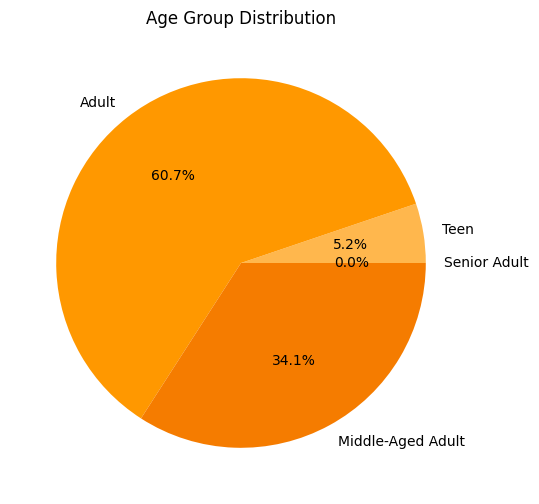

In [82]:
#Colour Pallete
orange_palette = ["#FFB74D", "#FF9800", "#F57C00", "#E65100"]

#Visualisasi using Pie Chart
plt.figure(figsize= (8, 6))
plt.pie(age_group_counts, labels= age_group_counts.index, autopct= "%1.1f%%", colors= orange_palette)
plt.title("Age Group Distribution")
plt.show()

Persebaran kategorisasi umur yang menggunakan E-commerce terbesar yakni 60.7% didominasi oleh umur 19-39 tahun (Adult), 34.1% Middle-Aged Adult umur 39-59 Tahun, Dan Teen sebesar 5.2% dengan rentang umur 13-19 tahun.

dan supringsingly untuk Senior adult tidak ada yang menggunakan e-commerce dalam berbelanja. Ini bisa jadi potensi untuk menciptakan pangsa/market baru dengan menaganalisa lebih lanjut kecenderungan Senior Adult untuk kita arahkan menggunakan platform E-commerce

## Gender
pada bagian ini kami akan melihat bagaimana sebaran jenis gender pada e-commerce

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Female'),
  Text(1, 0, 'Male'),
  Text(2, 0, 'Bigender'),
  Text(3, 0, 'Agender'),
  Text(4, 0, 'Genderfluid'),
  Text(5, 0, 'Non-binary'),
  Text(6, 0, 'Polygender'),
  Text(7, 0, 'Genderqueer')])

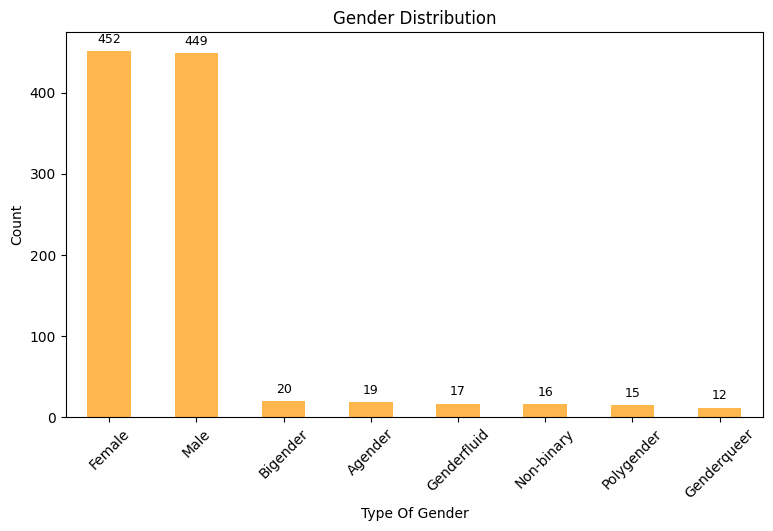

In [83]:
#Colour Pallete
gender_dt= df['Gender'].value_counts()

#Gender visualization
plt.figure(figsize= (9,5))
gender_dt.plot(kind="bar", color = ["#FFB74D"])

#Add Label on every bar
for index, value in enumerate(gender_dt):
    plt.text(index, value + 10, str(value), ha= 'center', fontsize = 9)

#Title
plt.title("Gender Distribution")
plt.xlabel("Type Of Gender")
plt.ylabel("Count")
plt.xticks(rotation= 45)


Dari barplot diatas dapat dilihat jika dominasi pengguna e-commerce dengan gender `Male` dan `Female`. 

## Unveiling the Purchase Amount on every month to see and drive strategy for campaign or promotion in the next year

In [84]:
#Change the Format data to Date Time
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'])

#Create the new column and split into month
df['Month_Purchased'] = df['Time_of_Purchase'].dt.month

Text(0.5, 1.0, 'Total Amount Purchased per Month')

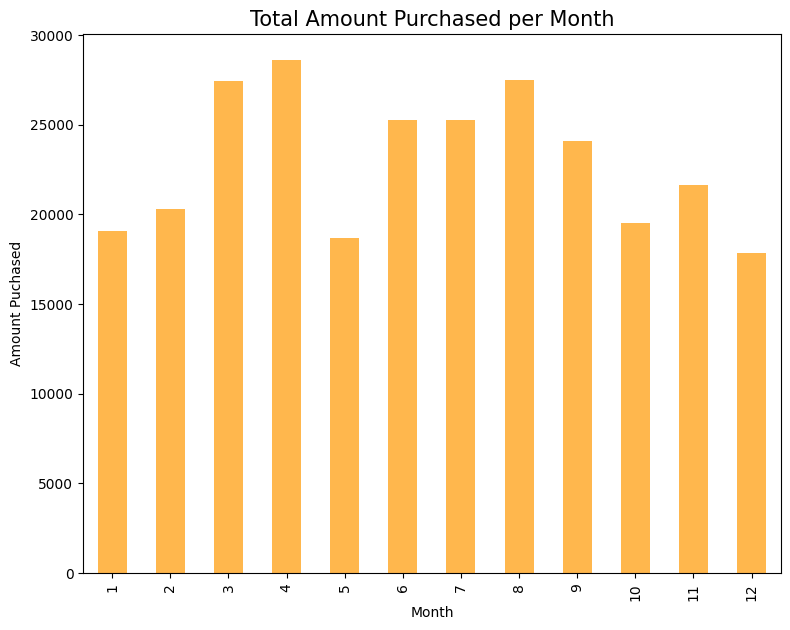

In [85]:
#Grouping Month based on Purchase amount
monthly_purchased = df.groupby('Month_Purchased')['Purchase_Amount'].sum()

plt.figure(figsize= (9,7))
monthly_purchased.plot(kind='bar', color = ["#FFB74D"]) 

#Information of Barplot
plt.xlabel("Month")
plt.ylabel("Amount Puchased")
plt.title("Total Amount Purchased per Month", size = 15)

- Dapat disimpulkan jika bulan April dan bulan Agustus merupakan bulan dengan Amount Purchased yang tinggi. 
- Kesimpulan selanjut dapat dilihat jika bulan Januari hingga April mengalami kenaikan yang cukup signifikan dan membentuk pola untuk setiap quarterly dari Januari - Desember selalu mengalami penuruna di bulan keempat di setiap quarternya

Dengan visualisasi ini dapat disimpulkan untuk membuat seasonal promo untuk di setiap quarter untuk mendorong pengguna agar tetap berbelanja dengan menggunakan platform e-commerce.

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Customer_ID                            1000 non-null   object        
 1   Age                                    1000 non-null   int64         
 2   Gender                                 1000 non-null   object        
 3   Income_Level                           1000 non-null   object        
 4   Marital_Status                         1000 non-null   object        
 5   Education_Level                        1000 non-null   object        
 6   Occupation                             1000 non-null   object        
 7   Location                               1000 non-null   object        
 8   Purchase_Category                      1000 non-null   object        
 9   Purchase_Amount                        1000 non-null   float64  

## Analisa Average Time decision untuk purchase 

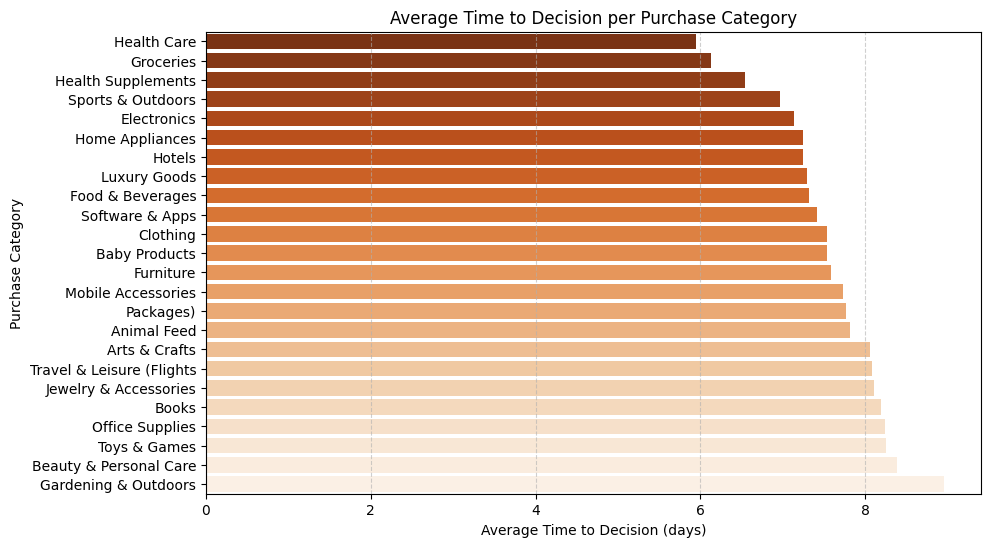

In [88]:
decision_time_by_category = df.groupby("Purchase_Category")["Time_to_Decision"].mean().sort_values()
# Optional: Visualizing
plt.figure(figsize=(10, 6))
sns.barplot(x=decision_time_by_category.values,
            y=decision_time_by_category.index,
            palette="Oranges_r")
plt.title("Average Time to Decision per Purchase Category")
plt.xlabel("Average Time to Decision (days)")
plt.ylabel("Purchase Category")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

setelah melihat barplot ini, kita dapat menyimpulkan bahwa Gardening & Outdoors memiliki waktu rata-rata keputusan pembelian terbanyak yaitu 8,9 hari dan top 5 keputusan pembelian tercepat berdasarkan kategori adalah Healt Care, Groceries, Healt Supplements, Sport & Outdoors, and Electronics.

Wawasan ini menunjukkan bahwa 5 hari keputusan rata-rata teratas (memutuskan untuk membeli dengan cepat) adalah jenis produk yang sering digunakan sebagai barang yang digunakan/dikonsumsi sehari-hari. 

Sekarang mari kita lihat bagaimana `Most_Common_Intent` melihat mode per Kategori Pembelian.

In [89]:
purchased_inten_byCat = df.groupby('Purchase_Category')['Purchase_Intent']\
                          .agg(lambda x: x.mode()[0])\
                          .reset_index(name='Most_Common_Intent')
purchased_inten_byCat[purchased_inten_byCat['Purchase_Category'].isin(['Health Care', 'Groceries', 'Health Supplements', 'Sports & Outdoors', 'Electronics'])]

,Purchase_Category,Most_Common_Intent
6,Electronics,Need-based
10,Groceries,Wants-based
11,Health Care,Planned
12,Health Supplements,Planned
21,Sports & Outdoors,Planned


Kita dapat melihat dari 5 kategori Pembelian Teratas yang `Most_Common_Intent` dari setiap Kategori Pembelian adalah:

- Electronics = Need-based
- Groceries = Wants-based
- Health Care = Planned
- Health Supplements = Planned
- Sports & Outdoords = Planned

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Customer_ID                            1000 non-null   object        
 1   Age                                    1000 non-null   int64         
 2   Gender                                 1000 non-null   object        
 3   Income_Level                           1000 non-null   object        
 4   Marital_Status                         1000 non-null   object        
 5   Education_Level                        1000 non-null   object        
 6   Occupation                             1000 non-null   object        
 7   Location                               1000 non-null   object        
 8   Purchase_Category                      1000 non-null   object        
 9   Purchase_Amount                        1000 non-null   float64  

## Segementation Analisis on Platform E-Commerce

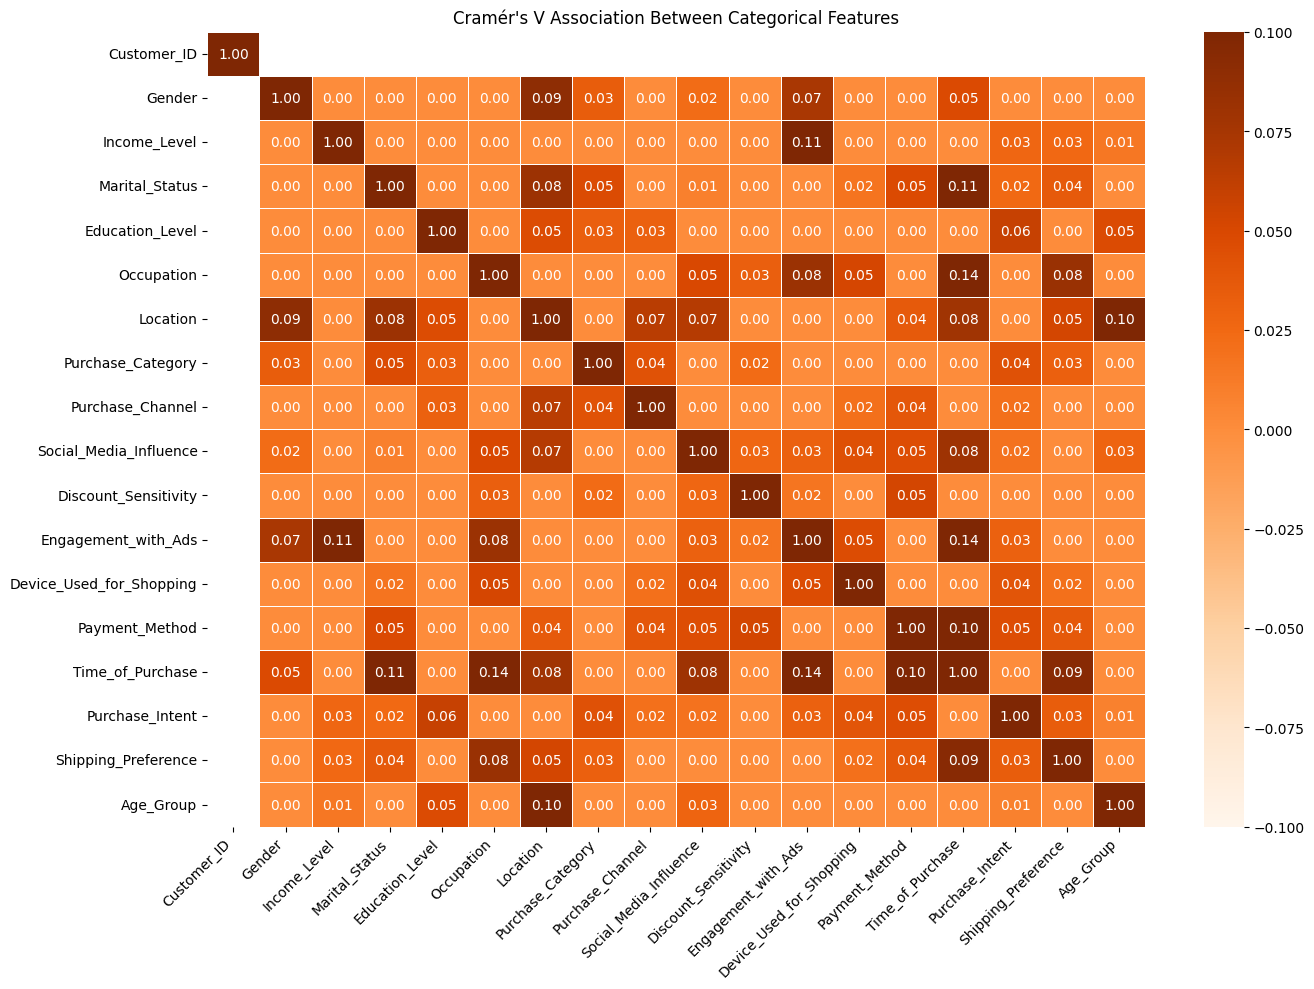

In [91]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Clean_Data.csv")

# Ambil kolom kategorikal
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Fungsi Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Matriks Cramér's V
cramers_matrix = pd.DataFrame(np.zeros((len(cat_cols), len(cat_cols))), 
                              index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 != col2:
            cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])
        else:
            cramers_matrix.loc[col1, col2] = 1.0

# Visualisasi heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap="Oranges", linewidths=0.5)
plt.title("Cramér's V Association Between Categorical Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Berdasarkan hasil analisa menggunakan Cramer's V method menunjukan jika rata-rata features pada data disini memiliki range (0.00 - 0.14). artinya fitur-fitur kategorikal disini cenderung independen satu sama lain, dan ini sangat ideal untuk segmentasi dengan K-Modes, karena:

1. Tidak ada fitur dominan yang mendikte bentuk klaster
2. Setiap fitur memberi warna yang berbeda ke dalam hasil klaster

In [92]:
selected_features = [
    'Gender',
    'Age_Group',
    'Income_Level',
    'Marital_Status',
    'Purchase_Category',
    'Purchase_Channel',
    'Discount_Sensitivity',
    'Purchase_Intent',
    'Device_Used_for_Shopping',
    'Shipping_Preference'
]

X = df[selected_features]

from sklearn.preprocessing import LabelEncoder

# **Encode categorical data into numerical values**
label_encoders = {}
for col in selected_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # Store encoders for later inverse transformation

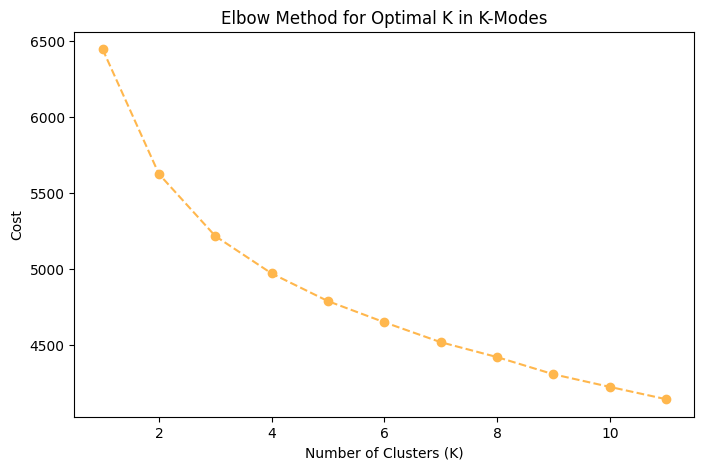

In [93]:
from kmodes.kmodes import KModes

# Run K-Modes for different K values and compute cost
costs = []
K_range = range(1, 12)

for k in K_range:
    km = KModes(n_clusters=k, init="Cao", n_init=5, verbose=0)
    km.fit_predict(X)
    costs.append(km.cost_)  # Cost is the measure of clustering quality

# Plot Elbow Method for K-Modes
plt.figure(figsize=(8, 5))
plt.plot(K_range, costs, marker="o", linestyle="--", color="#FFB74D")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Cost")
plt.title("Elbow Method for Optimal K in K-Modes")
plt.show()

In [94]:
# Apply K-Modes clustering with the optimal K from the elbow method
optimal_k = 3  # Based on elbow method
km = KModes(n_clusters=optimal_k, init="Cao", n_init=5, verbose=1)
df["Segment"] = km.fit_predict(X)
df["Segment"].unique()


Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 5215.0


array([0, 1, 2], dtype=uint16)

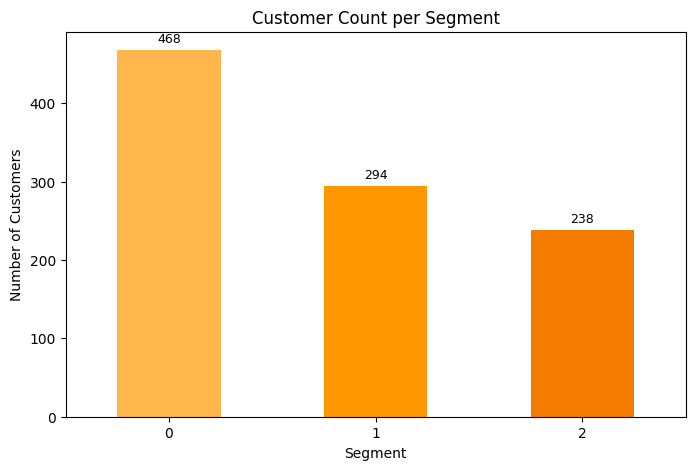

In [ ]:
# Count the number of customers in each segment
segment_counts = df["Segment"].value_counts()

# Plot the count of customers per segment
plt.figure(figsize=(8, 5))
for index, value in enumerate(segment_counts):
    plt.text(index, value + 10, str(value), ha= 'center', fontsize = 9)
segment_counts.plot(kind="bar", color= orange_palette)
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Count per Segment")
plt.xticks(rotation=0)
plt.show()

# Demographic Segmentation Analysis

<Figure size 1200x600 with 0 Axes>

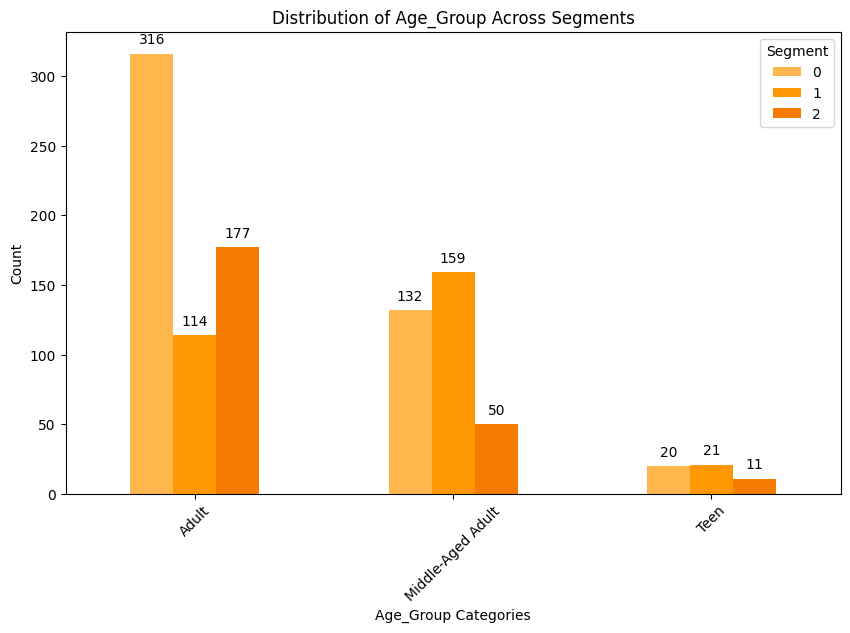

<Figure size 1200x600 with 0 Axes>

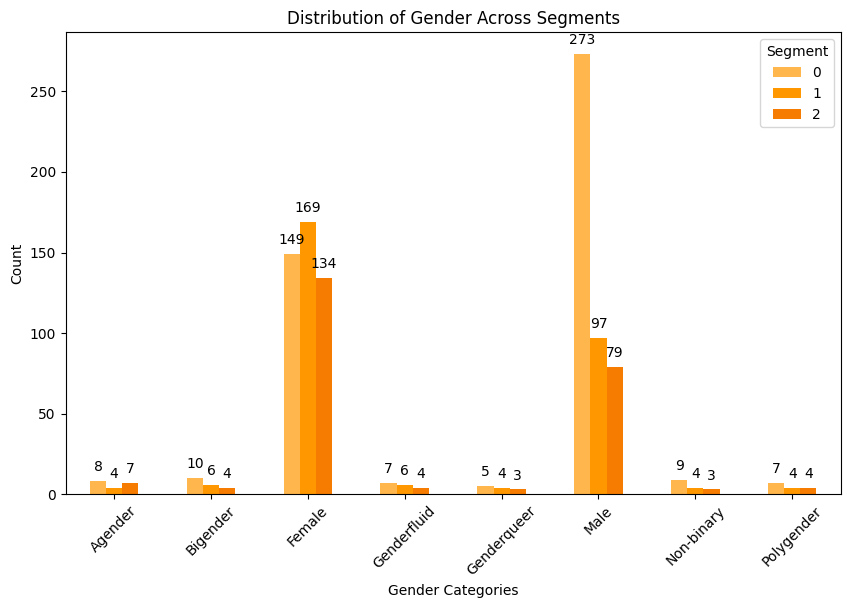

<Figure size 1200x600 with 0 Axes>

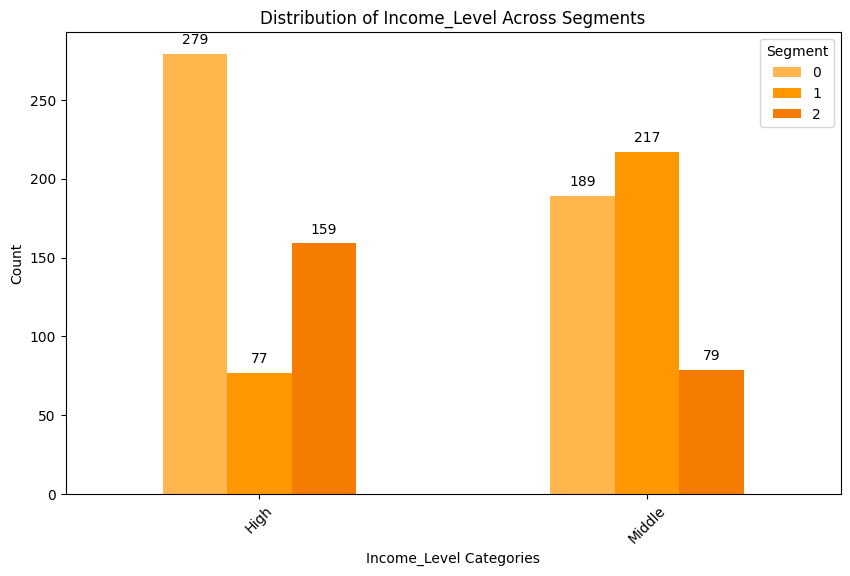

<Figure size 1200x600 with 0 Axes>

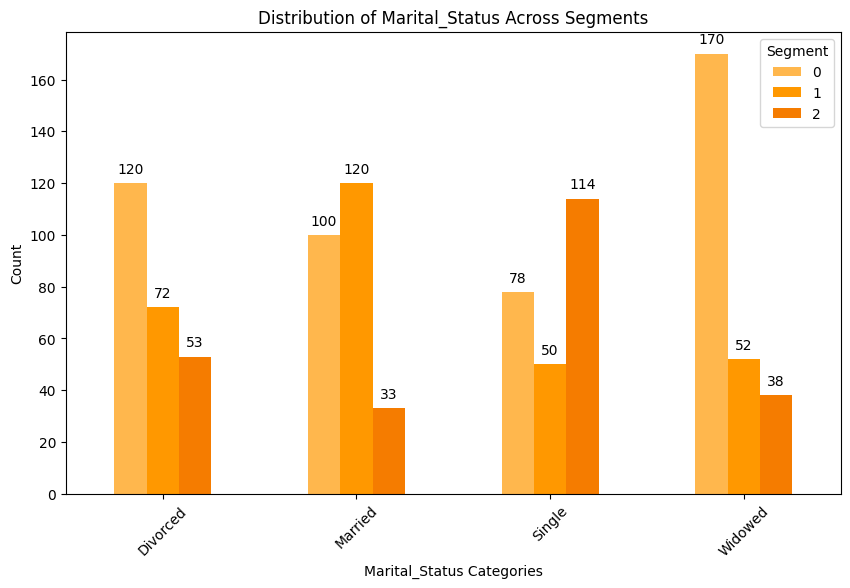

<Figure size 1200x600 with 0 Axes>

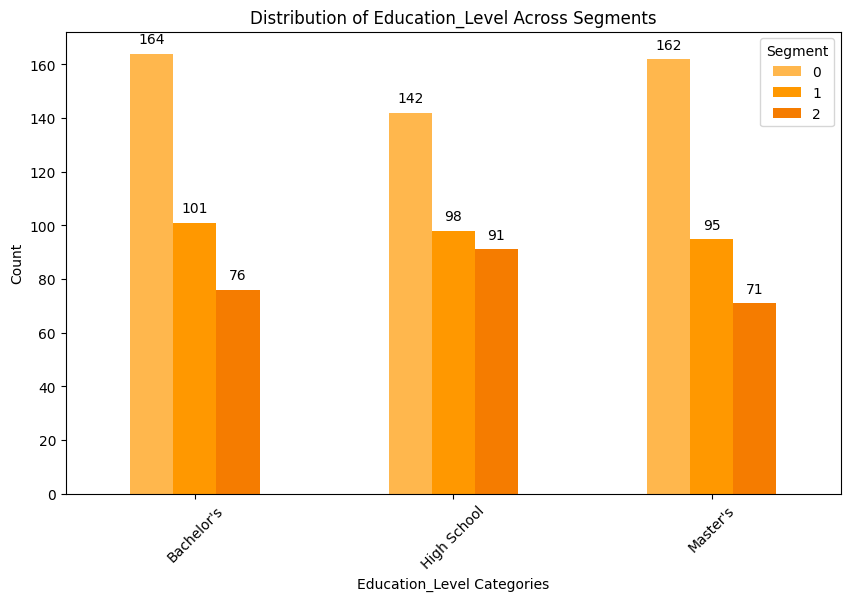

In [96]:
# Define shades of Orange for the bar charts
orange_palette = ["#FFB74D", "#FF9800", "#F57C00", "#E65100"] 

# Plot separate bar charts for each segment with blue color range
for feature in ["Age_Group", "Gender", "Income_Level", "Marital_Status", "Education_Level"]:
    plt.figure(figsize=(12, 6))
    
    # Count occurrences of each category per segment
    category_counts = df.groupby("Segment")[feature].value_counts().unstack()
        
    # Plot separate bar chart for each segment with blue colors
    ax = category_counts.T.plot(kind="bar", figsize=(10, 6), color=orange_palette)

    # Title and labels
    plt.title(f"Distribution of {feature} Across Segments")
    plt.xlabel(f"{feature} Categories")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Segment")

    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    xytext=(0, 5),  # Offset label
                    textcoords="offset points", 
                    ha='center', va='bottom', fontsize=10, color='black')

    # Show plot
    plt.show()

Setelah membagi ke dalam 3 Segmen/kelompok pelanggan E-Commerce, selanjutnya kita melihat bagaimana secara demografi segmentation berdasarkan Age Group, Gender, Income Level, Marital Status, and Education Level.

1. Pada Age Group :
- Secara kategori umur, pelanggan dengan kriteria 0 paling tinggi berada pada Adult
- Untuk Segment 1 dominan pada kategori umur Middle Aged Adult
- Sebaran segment paling rata terdapat pada kategori umur Teen2. 

2. Pada Gender :
- Secara gender mayoritas segment 0 berada pada kategori gender Male
- Untuk kategori gender male, mayoritas Segmentasi berada pada pelanggan tipe 13. 

3. Pada Income Category :
- Mayoritas segment 0 tertinggi pada income kategori High, dan segment 1 paling rendah pada income level ini.
- Pada Income level Middle tertinggi pada segment 0, lalu diikuti oleh segmen 1. 

4. Pada Marital Status :
- Segment 0 sangat mendominasi pada Status marital Divorced & Widowed, hal ini memberikan keunikan tersendiri pada segment ini.
- Segment 1 mendominasi pada status married, dan segment 2 mendominasi pada status single.

5. Pada Education Level :
- Dari ketiga category level edukasi yang terbagi atas Bachelor, High School, dan Master. Segment 0 merupakan segment paling mayoritas diantara kedua segment lainnya.

Setelah mengetahui analisa segementasi berdasarkan varible demografis, sekarang kita menganalisa bagaimana analisa segementasi behavioralnya.


# Behavioral Segmentation

<Figure size 1200x600 with 0 Axes>

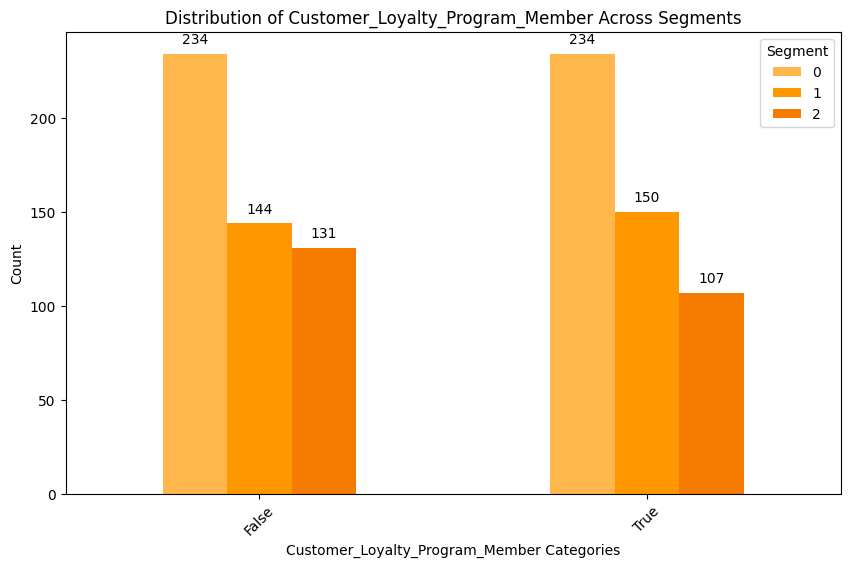

<Figure size 1200x600 with 0 Axes>

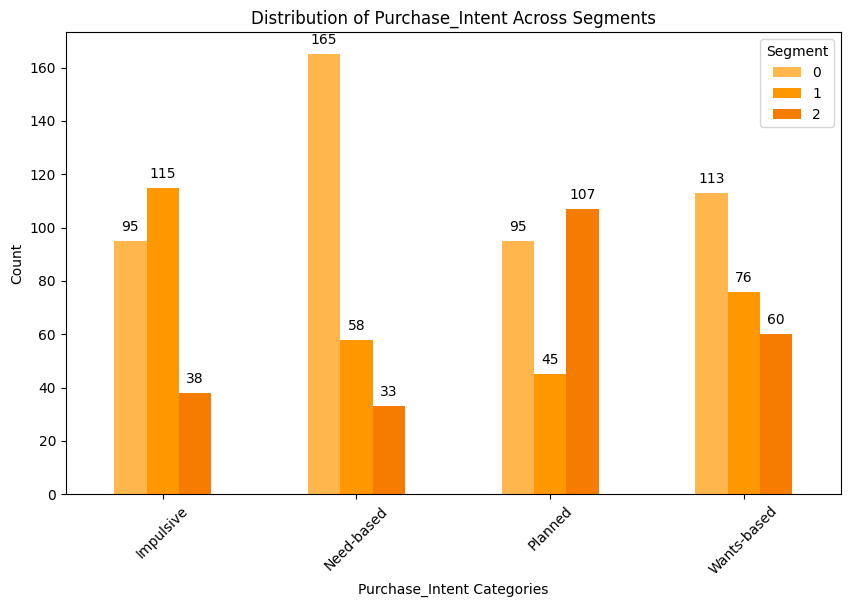

<Figure size 1200x600 with 0 Axes>

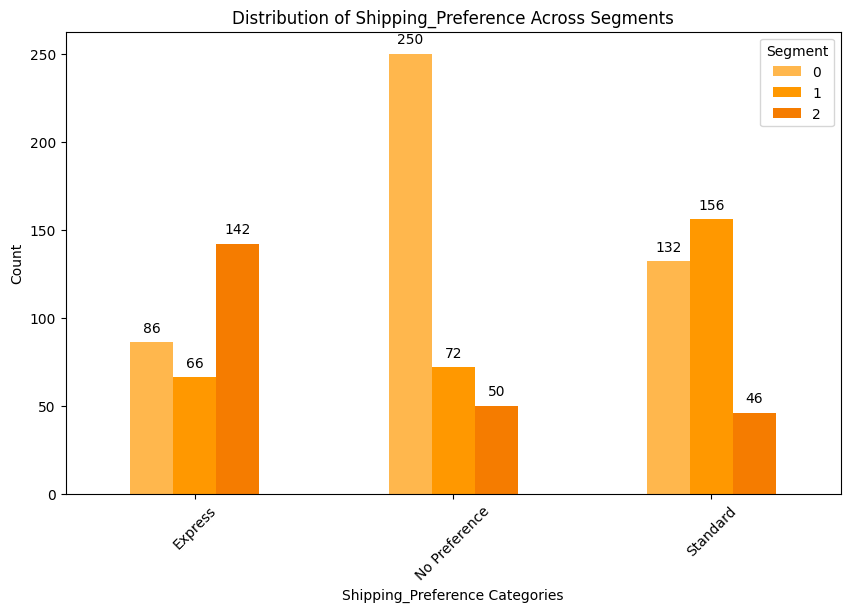

<Figure size 1200x600 with 0 Axes>

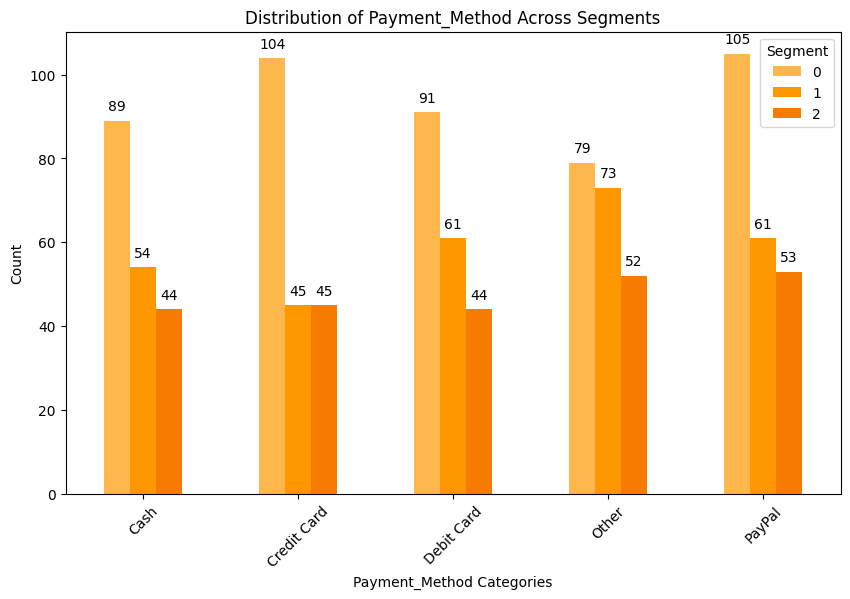

In [97]:
# Plot separate bar charts for each segment with blue color range
for feature in ["Customer_Loyalty_Program_Member", "Purchase_Intent", "Shipping_Preference", "Payment_Method"]:
    plt.figure(figsize=(12, 6))
    
    # Count occurrences of each category per segment
    category_counts = df.groupby("Segment")[feature].value_counts().unstack()
    
    # Plot separate bar chart for each segment with blue colors
    ax = category_counts.T.plot(kind="bar", figsize=(10, 6), color= orange_palette)

    # Title and labels
    plt.title(f"Distribution of {feature} Across Segments")
    plt.xlabel(f"{feature} Categories")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Segment")
    
    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    xytext=(0, 5),  # Offset label
                    textcoords="offset points", 
                    ha='center', va='bottom', fontsize=10, color='black')

    # Show plot
    plt.show()

Analisa dari behavioral ini dapat memberikan insight tentang perilaku pengguna E-commerce dengan beberapa fitur pilihan seperti Customer Loyalty, Purchase Intent, Shipping Preference, Payment Method.

1. Pada Customer Loyalty : 
- Segment 0 memiliki proporsi paling tinggi serta imbang pada kategori customer yang loyal ataupun customer yang tidak loyal, begitupun juga dengan segment
- Pada segment 2 proporsi tertinggi berada customer tidak loyal.
2. Pada Purchase Intent : 
- Secara mayoritas proporsi segment 0 terbesar pada perilaku membeli dengan kondisi Need-based dan Want-based.
- Segment 1 secara mayoritas proporsi paling tinggi berada pada perilaku membeli Impulsive. 
- Segment 2 paling tinggi ditemui pada kategori purchase intent Planned. Artinya customer pada segment ini cenderung melakukan pembelian secara rencana.
3. Pada Shipping Preference : 
- Segment 0 memiliki proporsi paling tinggi pada No Preference. Artinya segment 0 yang didominasi oleh Need-based serta want-based ini tidak mementingkan faktor preferensi pada shippingnya. 
- Jika kita melihat segment 1 secara proporsi paling tinggi pada preference Standard shipping.
- Untuk segment 2 paling tinggi berada pada shipping preference Express.

4. Pada Payment Method :
- Uang Tunai, Kartu Kredit, dan Kartu Debit digunakan secara merata di semua segmen, artinya pelanggan memiliki preferensi pembayaran yang fleksibel.
- PayPal sedikit lebih disukai di Segmen 2, yang mungkin menunjukkan bahwa kelompok ini lebih paham teknologi atau nyaman dengan pembayaran digital.
- Segmen 0 memiliki penggunaan tertinggi di antara semua metode pembayaran, yang memperkuat dominasinya sebagai kelompok terbesar dalam basis pelanggan.

# Key Take aways : Conclusion Insight with Persona
| Segment | Persona                    | Insight Utama                                         | Strategi Fokus                                                                 |
|---------|----------------------------|-------------------------------------------------------|---------------------------------------------------------------------------------|
| 0       | Promo-Savvy Mature Buyer   | Butuh produk yang relevan, fleksibel dalam belanja    | Bundle hemat, segmentasi produk berdasarkan kebutuhan, semua metode pembayaran |
| 1       | Impulsive Young Professional | Mudah tergoda promo, terbuka untuk loyalitas         | Urgensi, loyalty push, diskon singkat, reminder                                 |
| 2       | Rational Tech-Savvy Planner | Belanja berdasarkan rencana, cepat, digital          | Info produk jelas, express delivery, after-sales yang solid                    |
